<!--
Software Name : learning-parities-with-product-networks
SPDX-FileCopyrightText: Copyright (c) 2026 Orange S.A.
SPDX-License-Identifier: MIT

This software is distributed under the MIT License .,
see the "LICENSE.md" file for more details or https://opensource.org/licenses/MIT

Author: Guillaume Larue, guillaume.larue@orange.com
Software description: Source code of the paper "Learning High-Dimensional Parity Functions with Product Networks"
-->

# Study G — Joint Impact of $\alpha$, $p_e$, and Batch Size on Convergence

Explores how the number of steps to convergence depends jointly on problem size $N$, learning rate $\alpha$, dataset sparsity $p_e$, and batch size. Provides a comprehensive view of the hyperparameter interaction space.

**Data generated by:** [run_study_G.py](../studies/run_study_G.py)  
**Paper section:** Appendix G.5. Batch Size Requirements for Large Learning Rates (Figure 26)

| Parameter | Value |
|-----------|-------|
| Problem Size $N$          | [1, 100] (10 values, log spaced)  |
| Num. Parallel Nodes $P$   | $\lfloor 1000/N \rfloor$ |
| Learning Rate $\alpha$    | {1, N/10}           |
| Batch Size $M$            | {10, 100, 1000,10000}           |
| Bernouilli Prob. $p_e$    | {0.001, 1/N} |
| Max. Steps $S$            | 25000         | 
| Oracle Proportion $p_w$   | 0.5           |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import sys
import os
import glob

# Add parent directory to path
sys.path.append('..')

from plotting.plot_utility import setup_plot_style

%matplotlib inline
setup_plot_style()


In [2]:
def get_latest_study_folder(study_prefix):
    pattern = f'../studies/results/{study_prefix}_*/'
    folders = glob.glob(pattern)
    if folders:
        return max(folders)  # Latest by name (timestamp-based)
    return None

mode = 'auto'  # Change to 'manual' to specify your own path

if mode == 'auto':
    results_dir = get_latest_study_folder('G_alpha_p_e_batch')
    if results_dir is None:
        raise FileNotFoundError("No Study G results found. Run run_study_G.py first.")
    print(f"Auto-detected folder: {results_dir}")
else:
    results_dir = '../studies/results/G_alpha_p_e_batch_20260119_120906/'
    print(f"Using manual path: {results_dir}")

results_list = np.load(f'{results_dir}results_list.npy', allow_pickle=True).tolist()
alpha_types  = np.load(f'{results_dir}alpha_types.npy',  allow_pickle=True).item()
p_e_types    = np.load(f'{results_dir}p_e_types.npy',    allow_pickle=True).item()
n_values     = np.load(f'{results_dir}n_values.npy')
batch_sizes  = np.load(f'{results_dir}batch_sizes.npy')

print(f"\nN values: {n_values}")
print(f"Batch sizes: {batch_sizes}")
print(f"Alpha types: {alpha_types}")
print(f"p_e types:   {p_e_types}")
print(f"\nData structure: flat list of {len(results_list)} snapshots")
print(f"Snapshot keys: {list(results_list[0].keys()) if results_list else 'N/A'}")


Auto-detected folder: ../studies/results/G_alpha_p_e_batch_20260420_233418/

N values: [  10   16   27   46   77  129  215  359  599 1000]
Batch sizes: [   10   100  1000 10000]
Alpha types: {0: '1', 1: 'N/10'}
p_e types:   {0: '1/1000', 1: '1/N'}

Data structure: flat list of 160 snapshots
Snapshot keys: ['N', 'batch_size', 'alpha', 'p_e', 'alpha_type', 'p_e_type', 'steps', 'p_diff_history']


## Steps to Convergence vs $N$

Comprehensive visualisation of convergence time across all hyperparameter combinations, encoded as:
- **Colour**: batch size (viridis colormap)
- **Line style**: $\alpha$ value (solid / dashed / dotted)
- **Marker**: $p_e$ value (circle / square / triangle)

See Paper Appendix G.5 Figure 26.

In [3]:
# Build plot_data directly from the flat results_list using stored type indices
# plot_data[alpha_type][p_e_type][batch_size] = [(N, steps), ...]

plot_data = {}

for snapshot in results_list:
    steps = snapshot['steps']
    if steps <= 0:
        continue

    alpha_cat  = snapshot['alpha_type']
    p_e_cat    = snapshot['p_e_type']
    batch_size = snapshot['batch_size']
    N          = snapshot['N']

    if alpha_cat not in plot_data:
        plot_data[alpha_cat] = {}
    if p_e_cat not in plot_data[alpha_cat]:
        plot_data[alpha_cat][p_e_cat] = {}
    if batch_size not in plot_data[alpha_cat][p_e_cat]:
        plot_data[alpha_cat][p_e_cat][batch_size] = []

    plot_data[alpha_cat][p_e_cat][batch_size].append((N, steps))

# Sort each series by N
for alpha_cat in plot_data:
    for p_e_cat in plot_data[alpha_cat]:
        for batch_size in plot_data[alpha_cat][p_e_cat]:
            plot_data[alpha_cat][p_e_cat][batch_size].sort(key=lambda x: x[0])

print("Data organization complete!")
print(f"Alpha type keys: {sorted(plot_data.keys())}  ->  {alpha_types}")
if plot_data:
    first_alpha_cat = sorted(plot_data.keys())[0]
    print(f"p_e type keys for alpha_type={first_alpha_cat}: {sorted(plot_data[first_alpha_cat].keys())}  ->  {p_e_types}")


Data organization complete!
Alpha type keys: [0, 1]  ->  {0: '1', 1: 'N/10'}
p_e type keys for alpha_type=0: [0, 1]  ->  {0: '1/1000', 1: '1/N'}


/var/folders/1v/3smrwxkj7_x0r1cz_0ryqhhm0000gn/T/ipykernel_32184/771859517.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


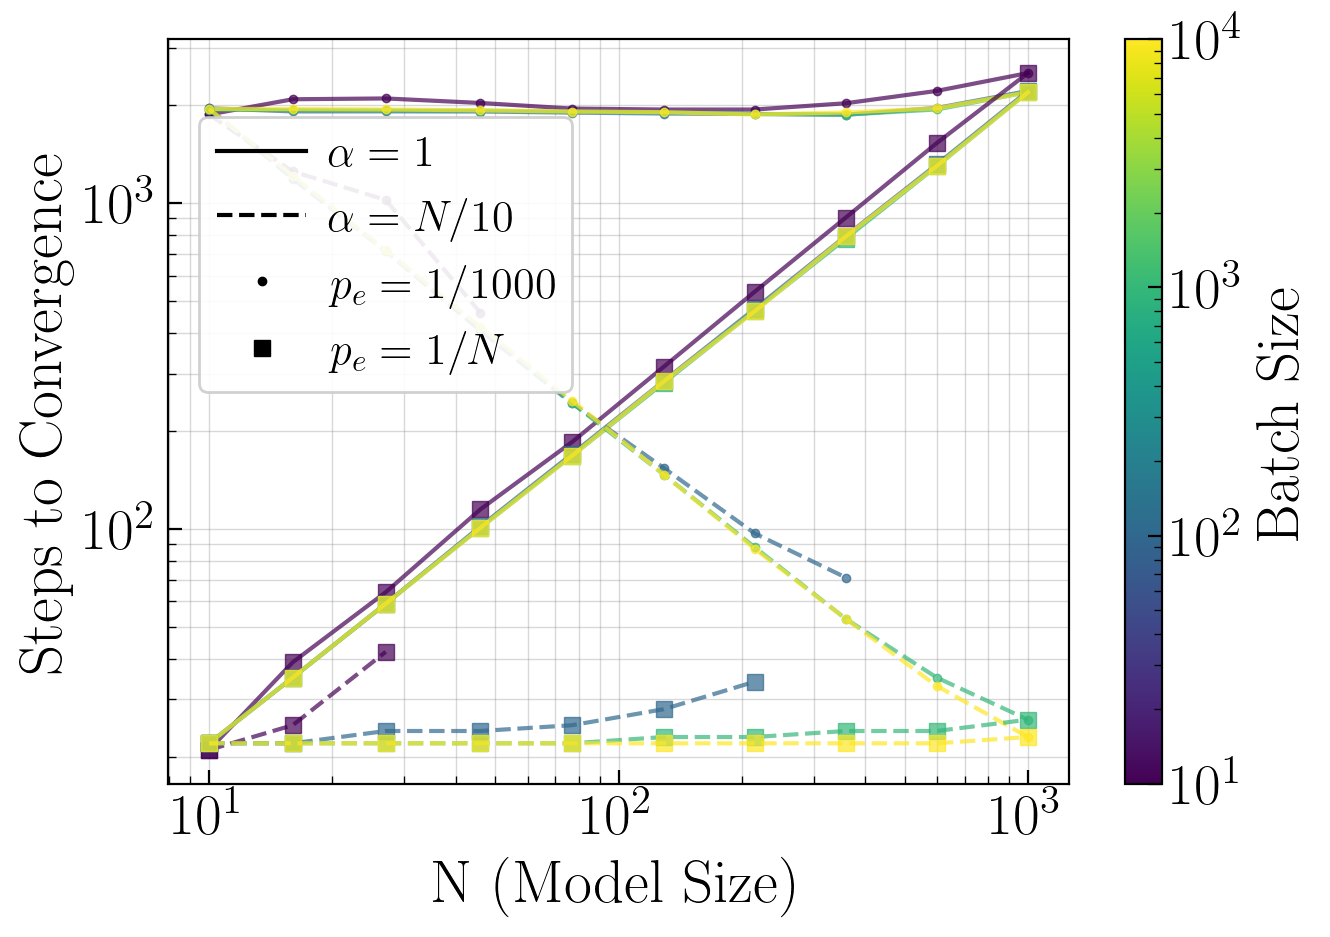

In [4]:
# Default style pools — extend as needed
_linestyle_pool = ['-', '--', ':', '-.']
_marker_pool    = ['.', 's', '^', 'D', 'v', 'o', 'x']

# Auto-assign a linestyle to each alpha_type key (sorted), with optional manual overrides
_alpha_linestyles_manual = {0: '-', 1: '--', 2: ':'}  # override or leave empty {}
alpha_linestyles = {
    k: _alpha_linestyles_manual.get(k, _linestyle_pool[i % len(_linestyle_pool)])
    for i, k in enumerate(sorted(alpha_types.keys()))
}

# Auto-assign a marker to each p_e_type key (sorted), with optional manual overrides
_p_e_markers_manual = {0: '.', 1: 's', 2: '^'}        # override or leave empty {}
p_e_markers = {
    k: _p_e_markers_manual.get(k, _marker_pool[i % len(_marker_pool)])
    for i, k in enumerate(sorted(p_e_types.keys()))
}

cmap = cm.get_cmap('viridis')
norm = mcolors.LogNorm(vmin=batch_sizes.min(), vmax=batch_sizes.max())

fig, ax = plt.subplots()

for alpha_cat in sorted(plot_data.keys()):
    for p_e_cat in sorted(plot_data[alpha_cat].keys()):
        for batch_size in batch_sizes:
            if batch_size not in plot_data[alpha_cat][p_e_cat]:
                continue

            data_points = plot_data[alpha_cat][p_e_cat][batch_size]
            N_list     = [point[0] for point in data_points]
            steps_list = [point[1] for point in data_points]

            if len(N_list) == 0:
                continue

            color     = cmap(norm(batch_size))
            linestyle = alpha_linestyles.get(alpha_cat, '-')
            marker    = p_e_markers.get(p_e_cat, 'o')

            ax.plot(N_list, steps_list,
                    color=color,
                    linestyle=linestyle,
                    marker=marker,
                    alpha=0.7)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Batch Size')

from matplotlib.lines import Line2D

# Build legend entries from the type mapping dicts
alpha_legend = [
    Line2D([0], [0], color='black', linestyle=alpha_linestyles.get(k, '-'),
           label=rf'$\alpha={v}$')
    for k, v in sorted(alpha_types.items())
]
p_e_legend = [
    Line2D([0], [0], color='black', marker=p_e_markers.get(k, 'o'), linestyle='',
           label=rf'$p_e={v}$')
    for k, v in sorted(p_e_types.items())
]
legend_elements = alpha_legend + p_e_legend

ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, 0.925), ncol=1)

ax.set_xlabel('N (Model Size)')
ax.set_ylabel('Steps to Convergence')
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()
